# M23 — Grid-density and reservoir-size robustness

**Author:** Ildefons Magrans de Abril  
**Affiliation:** Universitat Politècnica de Catalunya - BarcelonaTech (UPC)

**Purpose.** Test the temperature-path conclusions under a denser candidate grid and a larger reservoir, one factor at a time.

**Provenance.** Publication copy of the original executed M23 analysis notebook. Scientific code and frozen settings are preserved; only the notebook header and repository output path are cleaned for release.

The primary robustness quantities are safe-region enrichment, safe-minus-matched gain, and continuous association between prediction variation and available safe-region improvement. Singleton safe regions are excluded only from indicators that require two distinct safe candidates.

In [1]:
# ============================================================
# Imports and frozen configuration
# ============================================================

import os
import time
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# Set thread limits before expensive NumPy calls.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

GLOBAL_SEED = 20260718
OUTDIR = Path("tests/_m23_smoke_outputs")
OUTDIR.mkdir(exist_ok=True)

# Leave False for the paper-facing run. A separate smoke-test copy can set True.
SMOKE_TEST = True

INPUT_DIM = 2
INPUT_SCALE = 0.8
FIXED_BULK_SCALE = 1.0       # s0, fixed before scanning temperature
RIDGE = 1e-5
SAFE_ABS_TOL = 0.005
SAFE_REL_TOL = 0.10
TAU_MIN = 0.08
TAU_MAX = 3.50

WINDOW_SIZE = 50
WINDOW_STRIDE = 25
POSITIVE_GAIN_EPS = 1e-12

if SMOKE_TEST:
    TRIALS = 1
    TASKS = ["memory_d10"]
    T_TRAIN, T_VAL, T_TEST, WASHOUT = 120, 80, 120, 20
    CONFIGS = [
        {"config": "smoke_N20_K5_baseline", "N": 20, "K": 5},
        {"config": "smoke_N20_K9_finer_grid", "N": 20, "K": 9},
        {"config": "smoke_N30_K5_larger_reservoir", "N": 30, "K": 5},
    ]
    N_BOOT = 200
else:
    # Match the M20a train/validation/test lengths reported in the manuscript.
    TRIALS = 4
    TASKS = [
        "controlled_d20_white_plus_distractor",
        "memory_d10",
        "narma10",
        "lorenz_x",
    ]
    T_TRAIN, T_VAL, T_TEST, WASHOUT = 1200, 500, 500, 100
    CONFIGS = [
        {"config": "N60_K13_baseline", "N": 60, "K": 13},
        {"config": "N60_K25_finer_grid", "N": 60, "K": 25},
        {"config": "N150_K13_larger_reservoir", "N": 150, "K": 13},
    ]
    N_BOOT = 30000

print("M23 frozen-panel grid/size/dashboard robustness audit")
print("SMOKE_TEST:", SMOKE_TEST)
print("tasks:", TASKS)
print("trials:", TRIALS)
print("train/val/test:", T_TRAIN, T_VAL, T_TEST, "washout:", WASHOUT)
print("configs:")
for cfg in CONFIGS:
    print(" ", cfg)
print("output directory:", OUTDIR.resolve())

M23 frozen-panel grid/size/dashboard robustness audit
SMOKE_TEST: True
tasks: ['memory_d10']
trials: 1
train/val/test: 120 80 120 washout: 20
configs:
  {'config': 'smoke_N20_K5_baseline', 'N': 20, 'K': 5}
  {'config': 'smoke_N20_K9_finer_grid', 'N': 20, 'K': 9}
  {'config': 'smoke_N30_K5_larger_reservoir', 'N': 30, 'K': 5}
output directory: /mnt/data/temperature-calibrated-reservoirs-reproducibility/tests/_m23_smoke_outputs


In [2]:
# ============================================================
# General utilities
# ============================================================

def stable_int(text: str) -> int:
    value = 0
    for ch in str(text):
        value = (value * 131 + ord(ch)) % 10_000_000
    return int(value)


def stable_softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - np.max(x, axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / (np.sum(exp_z, axis=axis, keepdims=True) + 1e-12)


def normalize_series(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def add_bias(X: np.ndarray) -> np.ndarray:
    return np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)


def regression_metrics(y: np.ndarray, pred: np.ndarray) -> Dict[str, float]:
    y = np.asarray(y, dtype=float).reshape(-1)
    pred = np.asarray(pred, dtype=float).reshape(-1)
    mse = float(np.mean((pred - y) ** 2))
    rmse = float(np.sqrt(mse))
    nrmse = float(rmse / (np.std(y) + 1e-12))
    r2 = float(1.0 - mse / (np.var(y) + 1e-12))
    return {"mse": mse, "rmse": rmse, "nrmse": nrmse, "r2": r2}


def near_optimal_mask(scores: np.ndarray,
                      abs_tol: float = SAFE_ABS_TOL,
                      rel_tol: float = SAFE_REL_TOL) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    best = float(np.max(scores))
    span = float(np.max(scores) - np.min(scores))
    tolerance = max(abs_tol, rel_tol * max(span, 0.0))
    return scores >= best - tolerance


def contiguous_runs(mask: np.ndarray) -> List[Tuple[int, int]]:
    mask = np.asarray(mask, dtype=bool)
    runs = []
    i = 0
    while i < len(mask):
        if not mask[i]:
            i += 1
            continue
        j = i + 1
        while j < len(mask) and mask[j]:
            j += 1
        runs.append((i, j))
        i = j
    return runs


def component_containing(mask: np.ndarray, idx: int) -> np.ndarray:
    out = np.zeros_like(mask, dtype=bool)
    for lo, hi in contiguous_runs(mask):
        if lo <= idx < hi:
            out[lo:hi] = True
            return out
    out[int(idx)] = True
    return out


def all_contiguous_intervals(K: int, width: int) -> List[np.ndarray]:
    width = int(max(1, min(width, K)))
    return [np.arange(lo, lo + width, dtype=int) for lo in range(K - width + 1)]


def bootstrap_ci_mean(values: np.ndarray, n_boot: int, seed: int) -> Tuple[float, float, float]:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    if len(x) == 1:
        return float(x[0]), float(x[0]), float(x[0])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    boot = np.mean(x[idx], axis=1)
    return float(np.mean(x)), float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if len(a) < 3 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def log_grid_cell_fraction(log_values: np.ndarray, low_idx: int, high_idx: int) -> float:
    """Fraction of the scanned log-temperature domain occupied by grid cells in the region."""
    z = np.asarray(log_values, dtype=float)
    if len(z) == 1:
        return 1.0
    mids = 0.5 * (z[:-1] + z[1:])
    left = z[0] - 0.5 * (z[1] - z[0])
    right = z[-1] + 0.5 * (z[-1] - z[-2])
    edges = np.concatenate([[left], mids, [right]])
    return float((edges[high_idx + 1] - edges[low_idx]) / (edges[-1] - edges[0]))

In [3]:
# ============================================================
# Synthetic task generators (same task family as M20a)
# ============================================================

def as_two_channel(u0: np.ndarray, u1: Optional[np.ndarray] = None) -> np.ndarray:
    u0 = np.asarray(u0, dtype=float)
    if u1 is None:
        u1 = np.zeros_like(u0)
    return np.stack([normalize_series(u0), normalize_series(u1)], axis=1)


def make_ar1(T: int, rng: np.random.Generator, rho: float = 0.94) -> np.ndarray:
    x = np.zeros(T)
    eps = rng.normal(0.0, 1.0, size=T)
    for t in range(1, T):
        x[t] = rho * x[t - 1] + eps[t]
    return normalize_series(x)


def make_controlled(T: int, rng: np.random.Generator,
                    delay: int = 20, white: bool = True,
                    distractor: bool = True) -> Tuple[np.ndarray, np.ndarray]:
    extended = make_ar1(T + delay + 5, rng, rho=0.95)
    clean = extended[delay:delay + T]
    target = extended[:T]
    observed = clean.copy()
    if white:
        observed = observed + 0.75 * rng.normal(size=T)
    if distractor:
        second = make_ar1(T, rng, rho=0.97) + 0.25 * rng.normal(size=T)
    else:
        second = np.zeros(T)
    return as_two_channel(observed, second), normalize_series(target)


def make_memory_d10(T: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    delay = 10
    extended = rng.uniform(-1.0, 1.0, size=T + delay + 1)
    observed = extended[delay:delay + T]
    target = extended[:T]
    return as_two_channel(observed), normalize_series(target)


def make_narma10(T: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    order = 10
    warm = 150
    length = T + warm + order + 2
    u = rng.uniform(0.0, 0.5, size=length)
    y = np.zeros(length, dtype=float)
    for t in range(order, length - 1):
        y[t + 1] = (
            0.3 * y[t]
            + 0.05 * y[t] * np.sum(y[t - order + 1:t + 1])
            + 1.5 * u[t - order + 1] * u[t]
            + 0.1
        )
    start = warm + order
    observed = 2.0 * (u[start:start + T] - 0.25)
    target = normalize_series(y[start:start + T])
    return as_two_channel(observed), target



def make_lorenz_x(T: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    """One-step Lorenz-x prediction with a standardized two-channel input."""
    sigma, rho, beta, dt = 10.0, 28.0, 8.0 / 3.0, 0.01
    warm = 1200
    total = T + warm + 1
    state = np.array([
        1.0 + 0.01 * rng.normal(),
        1.0 + 0.01 * rng.normal(),
        1.0 + 0.01 * rng.normal(),
    ], dtype=float)
    xs = np.zeros(total, dtype=float)
    for t in range(total):
        xs[t] = state[0]
        x, y, z = state
        state = state + dt * np.array([
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z,
        ])
    series = normalize_series(xs[warm:warm + T + 1])
    return as_two_channel(series[:-1]), normalize_series(series[1:])

def make_task(task: str, T: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    if task == "memory_d10":
        return make_memory_d10(T, rng)
    if task == "narma10":
        return make_narma10(T, rng)
    if task == "controlled_d20_white_plus_distractor":
        return make_controlled(T, rng)
    if task == "lorenz_x":
        return make_lorenz_x(T, rng)
    raise ValueError(f"Unknown task: {task}")


def make_split(task: str, trial: int):
    # The data seed does not depend on N or K, so every configuration sees identical data.
    seed = GLOBAL_SEED + 100_000 * int(trial) + stable_int(task)
    rng = np.random.default_rng(seed)
    U_train, y_train = make_task(task, T_TRAIN + WASHOUT, rng)
    U_val, y_val = make_task(task, T_VAL + WASHOUT, rng)
    U_test, y_test = make_task(task, T_TEST + WASHOUT, rng)
    return (
        U_train[WASHOUT:], y_train[WASHOUT:],
        U_val[WASHOUT:], y_val[WASHOUT:],
        U_test[WASHOUT:], y_test[WASHOUT:],
    )

In [4]:
# ============================================================
# Temperature-controlled reservoir
# ============================================================

def rms_normalize_bulk(M: np.ndarray,
                       s0: float = FIXED_BULK_SCALE,
                       eps: float = 1e-12) -> np.ndarray:
    N = M.shape[0]
    rms = float(np.sqrt(np.mean(M ** 2)) + eps)
    return s0 * M / (np.sqrt(N) * rms)


def make_base_substrate(N: int, task: str, trial: int) -> Dict[str, np.ndarray]:
    # For fixed N/task/trial this seed is independent of K. Therefore K=13 and K=25
    # use exactly the same score/sign substrate and input matrix.
    seed = GLOBAL_SEED + 7_000_000 + 100_000 * int(trial) + 1_000 * int(N) + stable_int(task)
    rng = np.random.default_rng(seed)
    scores = rng.normal(0.0, 1.0, size=(N, N))
    np.fill_diagonal(scores, -1e9)
    signs = rng.choice([-1.0, 1.0], size=(N, N))
    np.fill_diagonal(signs, 0.0)
    Win = rng.uniform(-INPUT_SCALE, INPUT_SCALE, size=(N, INPUT_DIM))
    return {"scores": scores, "signs": signs, "Win": Win}


def make_temperature_grid(K: int) -> np.ndarray:
    return np.exp(np.linspace(np.log(TAU_MIN), np.log(TAU_MAX), int(K)))


def make_temperature_bank(base: Dict[str, np.ndarray], taus: np.ndarray) -> np.ndarray:
    matrices = []
    for tau in taus:
        allocation = stable_softmax(base["scores"] / float(tau), axis=1)
        signed = base["signs"] * allocation
        matrices.append(rms_normalize_bulk(signed))
    return np.stack(matrices, axis=0)


def rollout_bank(W_bank: np.ndarray, Win: np.ndarray, U: np.ndarray,
                 alpha: float = 1.0) -> np.ndarray:
    """Roll out every temperature candidate together.

    Returns shape (K, T, N). Batched execution makes the larger-N audit practical.
    """
    U = np.asarray(U, dtype=float)
    if U.ndim == 1:
        U = U.reshape(-1, 1)
    K, N, _ = W_bank.shape
    T = U.shape[0]
    states = np.zeros((K, N), dtype=np.float64)
    history = np.zeros((K, T, N), dtype=np.float64)
    for t in range(T):
        recurrent = np.einsum("kij,kj->ki", W_bank, states, optimize=True)
        drive = Win @ U[t]
        proposal = np.tanh(recurrent + drive[None, :])
        states = (1.0 - alpha) * states + alpha * proposal
        history[:, t, :] = states
    return history


def train_readout_bank(X_bank: np.ndarray, y: np.ndarray,
                       ridge: float = RIDGE) -> np.ndarray:
    outputs = []
    target = np.asarray(y, dtype=float).reshape(-1, 1)
    for X in X_bank:
        Xb = add_bias(X)
        D = Xb.shape[1]
        lhs = Xb.T @ Xb + ridge * np.eye(D)
        rhs = Xb.T @ target
        outputs.append(np.linalg.solve(lhs, rhs))
    return np.stack(outputs, axis=0)


def predict_readout_bank(X_bank: np.ndarray, Wout_bank: np.ndarray) -> np.ndarray:
    predictions = []
    for X, Wout in zip(X_bank, Wout_bank):
        predictions.append((add_bias(X) @ Wout).reshape(-1))
    return np.stack(predictions, axis=0)


def spectral_radius(W: np.ndarray) -> float:
    return float(np.max(np.abs(np.linalg.eigvals(W))))


def structural_metrics(W: np.ndarray) -> Dict[str, float]:
    absolute = np.abs(W)
    row_prob = absolute / (np.sum(absolute, axis=1, keepdims=True) + 1e-12)
    row_entropy = -np.sum(row_prob * np.log(row_prob + 1e-12), axis=1)
    effective_support = np.exp(row_entropy)
    return {
        "effective_support_mean": float(np.mean(effective_support)),
        "effective_support_fraction": float(np.mean(effective_support) / W.shape[0]),
        "row_entropy_mean": float(np.mean(row_entropy)),
        "rms_weight": float(np.sqrt(np.mean(W ** 2))),
        "spectral_radius": spectral_radius(W),
    }

In [5]:
# ============================================================
# Calibration, same-width controls, and window dashboard
# ============================================================

def calibrate_safe_region(validation_scores: np.ndarray) -> Dict:
    default_idx = int(np.argmax(validation_scores))
    superlevel = near_optimal_mask(validation_scores)
    safe_mask = component_containing(superlevel, default_idx)
    safe_idxs = np.where(safe_mask)[0]
    return {
        "default_idx": default_idx,
        "safe_mask": safe_mask,
        "safe_idxs": safe_idxs,
        "safe_low_idx": int(safe_idxs[0]),
        "safe_high_idx": int(safe_idxs[-1]),
        "safe_width": int(len(safe_idxs)),
    }


def matched_interval_stats(test_scores: np.ndarray,
                           default_idx: int,
                           width: int) -> Dict[str, float]:
    near_mask = near_optimal_mask(test_scores)
    oracle_idx = int(np.argmax(test_scores))
    default_score = float(test_scores[default_idx])
    near_hits, oracle_hits, gains = [], [], []
    for idxs in all_contiguous_intervals(len(test_scores), width):
        near_hits.append(float(np.any(near_mask[idxs])))
        oracle_hits.append(float(oracle_idx in idxs))
        gains.append(float(np.max(test_scores[idxs]) - default_score))
    return {
        "matched_near_rate": float(np.mean(near_hits)),
        "matched_oracle_rate": float(np.mean(oracle_hits)),
        "matched_best_gain": float(np.mean(gains)),
        "n_matched_intervals": int(len(gains)),
    }


def window_slices(T: int, size: int = WINDOW_SIZE, stride: int = WINDOW_STRIDE):
    if T <= size:
        yield 0, T
        return
    for start in range(0, T - size + 1, stride):
        yield start, start + size



def compute_window_rows(config: str, N: int, K: int, task: str, trial: int,
                        taus: np.ndarray, safe_idxs: np.ndarray, default_idx: int,
                        predictions: np.ndarray, y_test: np.ndarray,
                        train_target_scale: float) -> List[Dict]:
    rows = []
    safe_width = int(len(safe_idxs))
    dashboard_defined = safe_width >= 2
    safe_low = int(safe_idxs[0])
    safe_high = int(safe_idxs[-1])
    log_taus = np.log(taus)
    case_id = f"{task}__trial{trial}"

    for window_id, (lo, hi) in enumerate(window_slices(len(y_test))):
        y = y_test[lo:hi]
        pred_window = predictions[:, lo:hi]
        scale = float(train_target_scale + 1e-12)

        rmse = np.sqrt(np.mean((pred_window - y[None, :]) ** 2, axis=1))
        utility = -rmse / scale
        default_utility = float(utility[default_idx])
        safe_gain = float(np.max(utility[safe_idxs]) - default_utility)
        full_gain = float(np.max(utility) - default_utility)

        if dashboard_defined:
            safe_pred = pred_window[safe_idxs]
            dispersion = float(np.mean(np.std(safe_pred, axis=0)) / scale)
            anchor_spread = float(
                np.sqrt(np.mean((pred_window[safe_low] - pred_window[safe_high]) ** 2)) / scale
            )
            derivative_terms = []
            for left, right in zip(safe_idxs[:-1], safe_idxs[1:]):
                delta = max(log_taus[right] - log_taus[left], 1e-12)
                change = np.sqrt(
                    np.mean((pred_window[right] - pred_window[left]) ** 2)
                ) / scale
                derivative_terms.append(change / delta)
            local_log_sensitivity = float(np.mean(derivative_terms))
        else:
            dispersion = np.nan
            anchor_spread = np.nan
            local_log_sensitivity = np.nan

        rows.append({
            "config": config, "N": N, "K": K,
            "task": task, "trial": int(trial), "case_id": case_id,
            "window_id": int(window_id), "window_start": int(lo), "window_end": int(hi),
            "safe_width": safe_width,
            "dashboard_defined": bool(dashboard_defined),
            "safe_gain": safe_gain,
            "full_gain": full_gain,
            "positive_safe_gain": int(safe_gain > POSITIVE_GAIN_EPS),
            "safe_dispersion": dispersion,
            "anchor_spread": anchor_spread,
            "local_log_sensitivity": local_log_sensitivity,
        })
    return rows


In [6]:
# ============================================================
# Execute the audit
# ============================================================

point_rows = []
structural_rows = []
case_rows = []
window_rows = []

start_time = time.time()
case_counter = 0
n_cases = len(CONFIGS) * len(TASKS) * TRIALS

for cfg in CONFIGS:
    config = cfg["config"]
    N, K = int(cfg["N"]), int(cfg["K"])
    taus = make_temperature_grid(K)
    log_taus = np.log(taus)

    for task in TASKS:
        for trial in range(TRIALS):
            case_counter += 1
            print(f"[{case_counter:02d}/{n_cases}] {config} | {task} | trial={trial}")

            U_train, y_train, U_val, y_val, U_test, y_test = make_split(task, trial)
            base = make_base_substrate(N, task, trial)
            W_bank = make_temperature_bank(base, taus)

            # Structural measurements are recorded once per candidate.
            for point_idx, (tau, W) in enumerate(zip(taus, W_bank)):
                sm = structural_metrics(W)
                sm.update({
                    "config": config, "N": N, "K": K,
                    "task": task, "trial": int(trial),
                    "point_idx": int(point_idx), "tau": float(tau),
                })
                structural_rows.append(sm)

            X_train = rollout_bank(W_bank, base["Win"], U_train)
            Wout = train_readout_bank(X_train, y_train)
            del X_train

            X_val = rollout_bank(W_bank, base["Win"], U_val)
            pred_val = predict_readout_bank(X_val, Wout)
            del X_val

            X_test = rollout_bank(W_bank, base["Win"], U_test)
            pred_test = predict_readout_bank(X_test, Wout)
            del X_test

            val_metrics = [regression_metrics(y_val, p) for p in pred_val]
            test_metrics = [regression_metrics(y_test, p) for p in pred_test]
            val_nrmse = np.array([m["nrmse"] for m in val_metrics])
            test_nrmse = np.array([m["nrmse"] for m in test_metrics])
            val_scores = -val_nrmse
            test_scores = -test_nrmse

            for point_idx, tau in enumerate(taus):
                point_rows.append({
                    "config": config, "N": N, "K": K,
                    "task": task, "trial": int(trial),
                    "point_idx": int(point_idx), "tau": float(tau),
                    "val_nrmse": float(val_nrmse[point_idx]),
                    "test_nrmse": float(test_nrmse[point_idx]),
                    "val_score": float(val_scores[point_idx]),
                    "test_score": float(test_scores[point_idx]),
                })

            calibration = calibrate_safe_region(val_scores)
            safe_idxs = calibration["safe_idxs"]
            default_idx = calibration["default_idx"]
            oracle_idx = int(np.argmax(test_scores))
            test_near = near_optimal_mask(test_scores)
            matched = matched_interval_stats(test_scores, default_idx, calibration["safe_width"])

            safe_gain = float(np.max(test_scores[safe_idxs]) - test_scores[default_idx])
            full_gain = float(test_scores[oracle_idx] - test_scores[default_idx])
            safe_contains_near = int(np.any(test_near[safe_idxs]))
            safe_contains_oracle = int(oracle_idx in safe_idxs)

            case_struct = pd.DataFrame([
                row for row in structural_rows
                if row["config"] == config and row["task"] == task and row["trial"] == trial
            ])
            support_range = float(case_struct["effective_support_mean"].max() - case_struct["effective_support_mean"].min())
            support_fraction_range = float(case_struct["effective_support_fraction"].max() - case_struct["effective_support_fraction"].min())
            spectral_range = float(case_struct["spectral_radius"].max() - case_struct["spectral_radius"].min())

            case_rows.append({
                "config": config, "N": N, "K": K,
                "task": task, "trial": int(trial),
                "case_id": f"{task}__trial{trial}",
                "default_idx": int(default_idx),
                "default_tau": float(taus[default_idx]),
                "safe_low_idx": int(calibration["safe_low_idx"]),
                "safe_high_idx": int(calibration["safe_high_idx"]),
                "safe_low_tau": float(taus[calibration["safe_low_idx"]]),
                "safe_high_tau": float(taus[calibration["safe_high_idx"]]),
                "safe_width": int(calibration["safe_width"]),
                "safe_width_fraction": float(calibration["safe_width"] / K),
                "safe_log_cell_fraction": log_grid_cell_fraction(
                    log_taus, calibration["safe_low_idx"], calibration["safe_high_idx"]
                ),
                "safe_log_center_span_fraction": float(
                    (log_taus[calibration["safe_high_idx"]] - log_taus[calibration["safe_low_idx"]])
                    / (log_taus[-1] - log_taus[0] + 1e-12)
                ),
                "test_oracle_idx": int(oracle_idx),
                "test_oracle_tau": float(taus[oracle_idx]),
                "safe_contains_near": safe_contains_near,
                "safe_contains_oracle": safe_contains_oracle,
                "matched_near_rate": matched["matched_near_rate"],
                "matched_oracle_rate": matched["matched_oracle_rate"],
                "containment_lift_near_case": float(safe_contains_near / (matched["matched_near_rate"] + 1e-12)),
                "containment_lift_oracle_case": float(safe_contains_oracle / (matched["matched_oracle_rate"] + 1e-12)),
                "default_test_nrmse": float(test_nrmse[default_idx]),
                "safe_best_test_nrmse": float(np.min(test_nrmse[safe_idxs])),
                "full_oracle_test_nrmse": float(test_nrmse[oracle_idx]),
                "safe_gain": safe_gain,
                "full_oracle_gain": full_gain,
                "matched_best_gain": matched["matched_best_gain"],
                "safe_minus_matched_gain": float(safe_gain - matched["matched_best_gain"]),
                "support_range": support_range,
                "support_fraction_range": support_fraction_range,
                "spectral_radius_range": spectral_range,
            })

            window_rows.extend(compute_window_rows(
                config=config, N=N, K=K, task=task, trial=trial,
                taus=taus, safe_idxs=safe_idxs, default_idx=default_idx,
                predictions=pred_test, y_test=y_test,
                train_target_scale=float(np.std(y_train) + 1e-12),
            ))

elapsed = time.time() - start_time
print(f"Completed in {elapsed / 60:.2f} minutes")

point_df = pd.DataFrame(point_rows)
structural_df = pd.DataFrame(structural_rows)
case_df = pd.DataFrame(case_rows)
window_df = pd.DataFrame(window_rows)

point_df.to_csv(OUTDIR / "m22_point_metrics.csv", index=False)
structural_df.to_csv(OUTDIR / "m22_structural_metrics.csv", index=False)
case_df.to_csv(OUTDIR / "m22_case_metrics.csv", index=False)
window_df.to_csv(OUTDIR / "m22_window_metrics.csv", index=False)

print("cases:", len(case_df), "windows:", len(window_df), "candidate rows:", len(point_df))
case_df.head()

[01/3] smoke_N20_K5_baseline | memory_d10 | trial=0
[02/3] smoke_N20_K9_finer_grid | memory_d10 | trial=0
[03/3] smoke_N30_K5_larger_reservoir | memory_d10 | trial=0
Completed in 0.00 minutes
cases: 3 windows: 9 candidate rows: 19


,config,N,K,task,trial,case_id,default_idx,default_tau,safe_low_idx,safe_high_idx,safe_low_tau,safe_high_tau,safe_width,safe_width_fraction,safe_log_cell_fraction,safe_log_center_span_fraction,test_oracle_idx,test_oracle_tau,safe_contains_near,safe_contains_oracle,matched_near_rate,matched_oracle_rate,containment_lift_near_case,containment_lift_oracle_case,default_test_nrmse,safe_best_test_nrmse,full_oracle_test_nrmse,safe_gain,full_oracle_gain,matched_best_gain,safe_minus_matched_gain,support_range,support_fraction_range,spectral_radius_range
0,smoke_N20_K5_baseline,20,5,memory_d10,0,memory_d10__trial0,2,0.52915,2,2,0.52915,0.52915,1,0.200000,0.200000,0.0,2,0.529150,1,1,0.400000,0.200000,2.5,5.0,1.045968,1.045968,1.045968,0.0,0.000000,-0.033149,0.033149,16.803121,0.840156,0.056166
1,smoke_N20_K9_finer_grid,20,9,memory_d10,0,memory_d10__trial0,4,0.52915,4,4,0.52915,0.52915,1,0.111111,0.111111,0.0,5,0.848597,0,0,0.111111,0.111111,0.0,0.0,1.045968,1.045968,1.034159,0.0,0.011809,-0.032226,0.032226,16.803121,0.840156,0.058144
2,smoke_N30_K5_larger_reservoir,30,5,memory_d10,0,memory_d10__trial0,4,3.50000,4,4,3.50000,3.50000,1,0.200000,0.200000,0.0,1,0.205747,0,0,0.400000,0.200000,0.0,0.0,1.206883,1.206883,1.112305,0.0,0.094578,0.055822,-0.055822,26.225764,0.874192,0.178483


In [7]:
# ============================================================
# Aggregate core robustness metrics with case-level bootstrap CIs
# ============================================================

metric_specs = [
    "safe_width_fraction",
    "safe_log_cell_fraction",
    "safe_contains_near",
    "safe_contains_oracle",
    "matched_near_rate",
    "matched_oracle_rate",
    "safe_gain",
    "matched_best_gain",
    "safe_minus_matched_gain",
    "support_fraction_range",
    "spectral_radius_range",
]

summary_rows = []
for config, group in case_df.groupby("config", sort=False):
    row = {
        "config": config,
        "N": int(group["N"].iloc[0]),
        "K": int(group["K"].iloc[0]),
        "n_cases": int(len(group)),
    }
    for metric in metric_specs:
        mean, low, high = bootstrap_ci_mean(
            group[metric].to_numpy(), N_BOOT,
            GLOBAL_SEED + stable_int(config + metric),
        )
        row[metric] = mean
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high

    # Ratio of aggregate rates is more interpretable than the mean of per-case ratios.
    row["containment_lift_near"] = float(
        row["safe_contains_near"] / (row["matched_near_rate"] + 1e-12)
    )
    row["containment_lift_oracle"] = float(
        row["safe_contains_oracle"] / (row["matched_oracle_rate"] + 1e-12)
    )
    summary_rows.append(row)

core_summary = pd.DataFrame(summary_rows)
core_summary.to_csv(OUTDIR / "m22_core_summary.csv", index=False)

columns_to_show = [
    "config", "N", "K", "n_cases",
    "safe_width_fraction", "safe_log_cell_fraction",
    "safe_contains_near", "matched_near_rate", "containment_lift_near",
    "safe_contains_oracle", "matched_oracle_rate", "containment_lift_oracle",
    "safe_gain", "safe_minus_matched_gain",
    "support_fraction_range", "spectral_radius_range",
]
core_summary[columns_to_show].round(5)

,config,N,K,n_cases,safe_width_fraction,safe_log_cell_fraction,safe_contains_near,matched_near_rate,containment_lift_near,safe_contains_oracle,matched_oracle_rate,containment_lift_oracle,safe_gain,safe_minus_matched_gain,support_fraction_range,spectral_radius_range
0,smoke_N20_K5_baseline,20,5,1,0.20000,0.20000,1.0,0.40000,2.5,1.0,0.20000,5.0,0.0,0.03315,0.84016,0.05617
1,smoke_N20_K9_finer_grid,20,9,1,0.11111,0.11111,0.0,0.11111,0.0,0.0,0.11111,0.0,0.0,0.03223,0.84016,0.05814
2,smoke_N30_K5_larger_reservoir,30,5,1,0.20000,0.20000,0.0,0.40000,0.0,0.0,0.20000,0.0,0.0,-0.05582,0.87419,0.17848


In [8]:
# ============================================================
# Corrected dashboard analysis
# ============================================================

PRIMARY_INDICATORS = ["safe_dispersion", "anchor_spread"]
ALL_INDICATORS = PRIMARY_INDICATORS + ["local_log_sensitivity"]


def prepare_indicator_groups(df: pd.DataFrame, indicator: str) -> pd.DataFrame:
    """Create disjoint within-case high/low quartile flags.

    Cases are excluded when:
      * the safe region has fewer than two points;
      * the indicator is non-finite;
      * the indicator is constant across windows.
    """
    pieces = []
    for (config, case_id), group in df.groupby(["config", "case_id"], sort=False):
        g = group.copy()
        valid = (
            g["dashboard_defined"].astype(bool)
            & np.isfinite(g[indicator].to_numpy(dtype=float))
        )
        g = g.loc[valid].copy()
        if len(g) < 4 or float(g[indicator].max() - g[indicator].min()) <= 1e-15:
            continue

        # Stable exact-count quartiles avoid overlapping high/low groups under ties.
        g = g.sort_values([indicator, "window_id"], kind="mergesort").reset_index(drop=True)
        qn = max(1, int(np.ceil(0.25 * len(g))))
        g[f"{indicator}_low_q25"] = False
        g[f"{indicator}_high_q75"] = False
        g.loc[g.index[:qn], f"{indicator}_low_q25"] = True
        g.loc[g.index[-qn:], f"{indicator}_high_q75"] = True
        pieces.append(g)

    if not pieces:
        cols = list(df.columns) + [f"{indicator}_low_q25", f"{indicator}_high_q75"]
        return pd.DataFrame(columns=cols)
    return pd.concat(pieces, ignore_index=True)


def safe_corr(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    if np.sum(ok) < 3 or np.std(x[ok]) <= 1e-15 or np.std(y[ok]) <= 1e-15:
        return np.nan
    return float(np.corrcoef(x[ok], y[ok])[0, 1])


def pooled_dashboard_stat(df: pd.DataFrame, indicator: str) -> Dict[str, float]:
    if len(df) == 0:
        return {
            "n_windows": 0, "n_cases": 0, "base_positive_rate": np.nan,
            "high_precision": np.nan, "low_precision": np.nan,
            "precision_lift": np.nan, "high_minus_low_positive_rate": np.nan,
            "high_minus_low_mean_gain": np.nan, "indicator_gain_corr": np.nan,
        }

    high = df[f"{indicator}_high_q75"].to_numpy(dtype=bool)
    low = df[f"{indicator}_low_q25"].to_numpy(dtype=bool)
    positive = df["positive_safe_gain"].to_numpy(dtype=float)
    gain = df["safe_gain"].to_numpy(dtype=float)
    values = df[indicator].to_numpy(dtype=float)

    base_rate = float(np.mean(positive))
    high_rate = float(np.mean(positive[high])) if np.any(high) else np.nan
    low_rate = float(np.mean(positive[low])) if np.any(low) else np.nan
    return {
        "n_windows": int(len(df)),
        "n_cases": int(df["case_id"].nunique()),
        "base_positive_rate": base_rate,
        "high_precision": high_rate,
        "low_precision": low_rate,
        "precision_lift": float(high_rate / base_rate)
            if np.isfinite(high_rate) and base_rate > 0 else np.nan,
        "high_minus_low_positive_rate": float(high_rate - low_rate)
            if np.isfinite(high_rate) and np.isfinite(low_rate) else np.nan,
        "high_minus_low_mean_gain": float(np.mean(gain[high]) - np.mean(gain[low]))
            if np.any(high) and np.any(low) else np.nan,
        "indicator_gain_corr": safe_corr(values, gain),
    }


def cluster_bootstrap_dashboard(df: pd.DataFrame, indicator: str,
                                n_boot: int, seed: int) -> Dict[str, Tuple[float, float]]:
    if len(df) == 0:
        return {}
    rng = np.random.default_rng(seed)
    case_ids = np.asarray(df["case_id"].unique())
    stats = {k: [] for k in [
        "precision_lift", "high_minus_low_positive_rate",
        "high_minus_low_mean_gain", "indicator_gain_corr"
    ]}
    for _ in range(int(n_boot)):
        sampled = rng.choice(case_ids, size=len(case_ids), replace=True)
        parts = []
        for draw_id, case_id in enumerate(sampled):
            part = df[df["case_id"] == case_id].copy()
            part["case_id"] = part["case_id"].astype(str) + f"__boot{draw_id}"
            parts.append(part)
        boot_df = pd.concat(parts, ignore_index=True)
        s = pooled_dashboard_stat(boot_df, indicator)
        for key in stats:
            stats[key].append(s[key])
    out = {}
    for key, values in stats.items():
        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        out[key] = (
            float(np.quantile(arr, 0.025)) if len(arr) else np.nan,
            float(np.quantile(arr, 0.975)) if len(arr) else np.nan,
        )
    return out


dashboard_rows = []
dashboard_eligible_rows = []

for indicator in ALL_INDICATORS:
    marked = prepare_indicator_groups(window_df, indicator)
    if len(marked):
        marked["indicator_name"] = indicator
        dashboard_eligible_rows.append(marked)

    for config in [cfg["config"] for cfg in CONFIGS]:
        sub = marked[marked["config"] == config].copy() if len(marked) else marked.copy()
        stat = pooled_dashboard_stat(sub, indicator)
        cis = cluster_bootstrap_dashboard(
            sub, indicator, N_BOOT,
            GLOBAL_SEED + stable_int("M23_" + config + indicator),
        )
        row = {"config": config, "indicator": indicator, **stat}
        for key, (low, high) in cis.items():
            row[f"{key}_ci_low"] = low
            row[f"{key}_ci_high"] = high
        dashboard_rows.append(row)

dashboard_summary = pd.DataFrame(dashboard_rows)
dashboard_eligible_df = (
    pd.concat(dashboard_eligible_rows, ignore_index=True)
    if dashboard_eligible_rows else pd.DataFrame()
)

dashboard_case_eligibility = (
    window_df.groupby(["config", "case_id"], as_index=False)
    .agg(
        safe_width=("safe_width", "first"),
        dashboard_defined=("dashboard_defined", "first"),
        n_windows=("window_id", "count"),
    )
)
dashboard_case_eligibility["exclusion_reason"] = np.where(
    dashboard_case_eligibility["dashboard_defined"],
    "",
    "singleton_safe_region",
)

dashboard_summary.to_csv(OUTDIR / "m23_dashboard_summary.csv", index=False)
dashboard_case_eligibility.to_csv(
    OUTDIR / "m23_dashboard_case_eligibility.csv", index=False
)
if len(dashboard_eligible_df):
    dashboard_eligible_df.to_csv(
        OUTDIR / "m23_dashboard_eligible_windows.csv", index=False
    )

print("Dashboard case eligibility:")
display(
    dashboard_case_eligibility.groupby("config", as_index=False)
    .agg(
        total_cases=("case_id", "count"),
        eligible_cases=("dashboard_defined", "sum"),
        mean_safe_width=("safe_width", "mean"),
    )
)
print("\nCorrected dashboard summary:")
display(dashboard_summary)

Dashboard case eligibility:


,config,total_cases,eligible_cases,mean_safe_width
0,smoke_N20_K5_baseline,1,0,1.0
1,smoke_N20_K9_finer_grid,1,0,1.0
2,smoke_N30_K5_larger_reservoir,1,0,1.0



Corrected dashboard summary:


,config,indicator,n_windows,n_cases,base_positive_rate,high_precision,low_precision,precision_lift,high_minus_low_positive_rate,high_minus_low_mean_gain,indicator_gain_corr
0,smoke_N20_K5_baseline,safe_dispersion,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,smoke_N20_K9_finer_grid,safe_dispersion,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,smoke_N30_K5_larger_reservoir,safe_dispersion,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,smoke_N20_K5_baseline,anchor_spread,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,smoke_N20_K9_finer_grid,anchor_spread,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,smoke_N30_K5_larger_reservoir,anchor_spread,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,smoke_N20_K5_baseline,local_log_sensitivity,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,smoke_N20_K9_finer_grid,local_log_sensitivity,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,smoke_N30_K5_larger_reservoir,local_log_sensitivity,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ============================================================
# Separate core and dashboard robustness gates
# ============================================================

BASELINE_NAME = CONFIGS[0]["config"]

primary_dash = dashboard_summary[
    dashboard_summary["indicator"].isin(PRIMARY_INDICATORS)
].copy()

dash_wide = primary_dash.pivot(
    index="config",
    columns="indicator",
    values=[
        "precision_lift",
        "high_minus_low_mean_gain",
        "indicator_gain_corr",
        "n_cases",
    ],
)
dash_wide.columns = [f"{metric}_{indicator}" for metric, indicator in dash_wide.columns]
dash_wide = dash_wide.reset_index()

paper_summary = core_summary.merge(dash_wide, on="config", how="left")

# Reviewer-facing core claim.
paper_summary["core_containment_pass"] = (
    paper_summary["containment_lift_near"] > 1.0
)
paper_summary["core_gain_pass"] = (
    paper_summary["safe_minus_matched_gain"] > 0.0
)
paper_summary["core_robustness_pass"] = (
    paper_summary["core_containment_pass"] & paper_summary["core_gain_pass"]
)

# Dashboard: continuous association is primary; binary precision is secondary.
paper_summary["dashboard_continuous_pass"] = (
    (
        (paper_summary["high_minus_low_mean_gain_safe_dispersion"] > 0.0)
        & (paper_summary["indicator_gain_corr_safe_dispersion"] > 0.0)
    )
    |
    (
        (paper_summary["high_minus_low_mean_gain_anchor_spread"] > 0.0)
        & (paper_summary["indicator_gain_corr_anchor_spread"] > 0.0)
    )
)
paper_summary["dashboard_binary_pass"] = (
    (paper_summary["precision_lift_safe_dispersion"] > 1.0)
    | (paper_summary["precision_lift_anchor_spread"] > 1.0)
)

comparison_metrics = [
    "safe_width_fraction",
    "safe_log_cell_fraction",
    "containment_lift_near",
    "containment_lift_oracle",
    "safe_gain",
    "safe_minus_matched_gain",
    "high_minus_low_mean_gain_safe_dispersion",
    "high_minus_low_mean_gain_anchor_spread",
    "indicator_gain_corr_safe_dispersion",
    "indicator_gain_corr_anchor_spread",
    "precision_lift_safe_dispersion",
    "precision_lift_anchor_spread",
    "support_fraction_range",
    "spectral_radius_range",
]

baseline = paper_summary.loc[
    paper_summary["config"] == BASELINE_NAME
].iloc[0]

comparison_rows = []
for _, row in paper_summary.iterrows():
    comp = {"config": row["config"], "relative_to": BASELINE_NAME}
    for metric in comparison_metrics:
        comp[f"{metric}_absolute"] = row.get(metric, np.nan)
        base_value = baseline.get(metric, np.nan)
        value = row.get(metric, np.nan)
        comp[f"{metric}_ratio"] = (
            float(value / base_value)
            if np.isfinite(value) and np.isfinite(base_value)
            and abs(base_value) > 1e-15 else np.nan
        )
    comparison_rows.append(comp)

pairwise_comparison = pd.DataFrame(comparison_rows)

paper_summary.to_csv(OUTDIR / "m23_paper_summary.csv", index=False)
pairwise_comparison.to_csv(OUTDIR / "m23_pairwise_comparison.csv", index=False)

print("Separate robustness decisions:")
display(paper_summary[[
    "config", "N", "K",
    "core_robustness_pass",
    "dashboard_continuous_pass",
    "dashboard_binary_pass",
    "containment_lift_near",
    "safe_minus_matched_gain",
    "high_minus_low_mean_gain_safe_dispersion",
    "high_minus_low_mean_gain_anchor_spread",
    "precision_lift_safe_dispersion",
    "precision_lift_anchor_spread",
]])

Separate robustness decisions:


,config,N,K,core_robustness_pass,dashboard_continuous_pass,dashboard_binary_pass,containment_lift_near,safe_minus_matched_gain,high_minus_low_mean_gain_safe_dispersion,high_minus_low_mean_gain_anchor_spread,precision_lift_safe_dispersion,precision_lift_anchor_spread
0,smoke_N20_K5_baseline,20,5,True,False,False,2.5,0.033149,NaN,NaN,NaN,NaN
1,smoke_N20_K9_finer_grid,20,9,False,False,False,0.0,0.032226,NaN,NaN,NaN,NaN
2,smoke_N30_K5_larger_reservoir,30,5,False,False,False,0.0,-0.055822,NaN,NaN,NaN,NaN


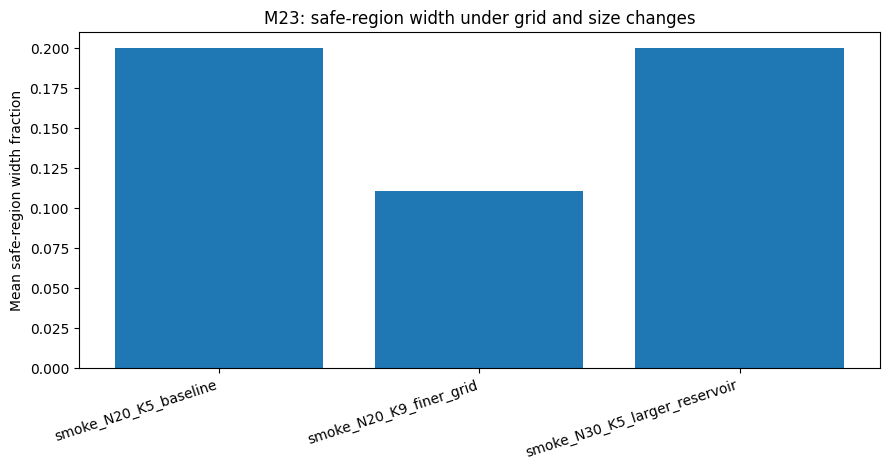

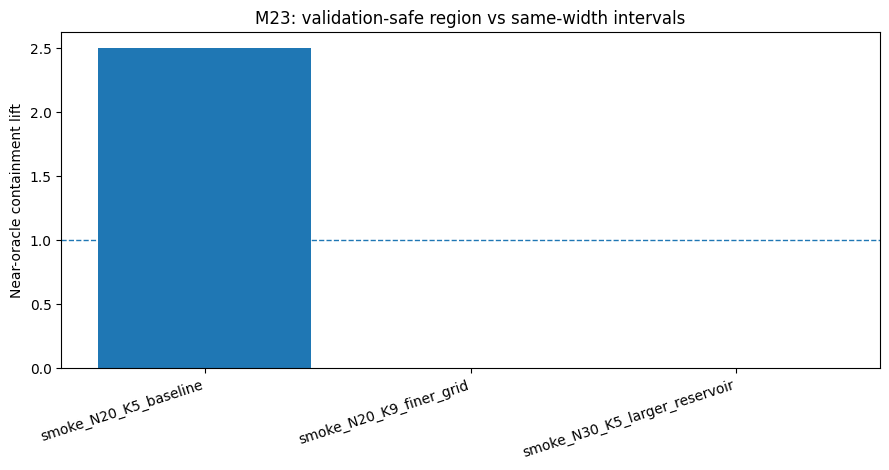

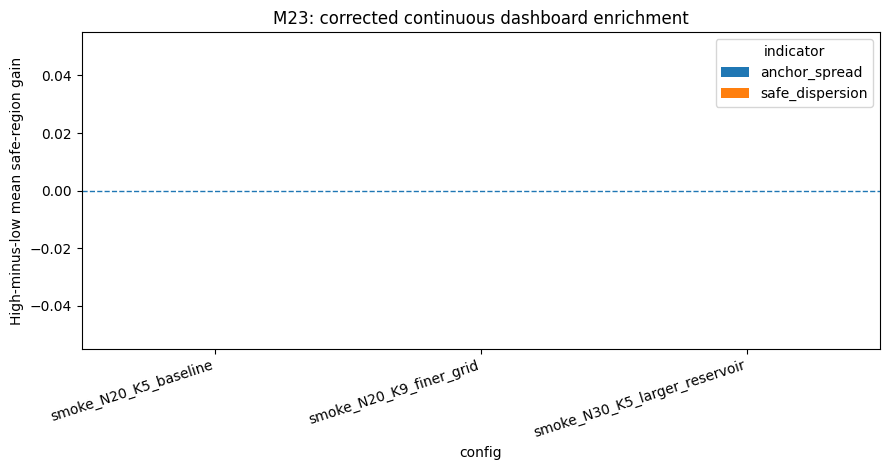

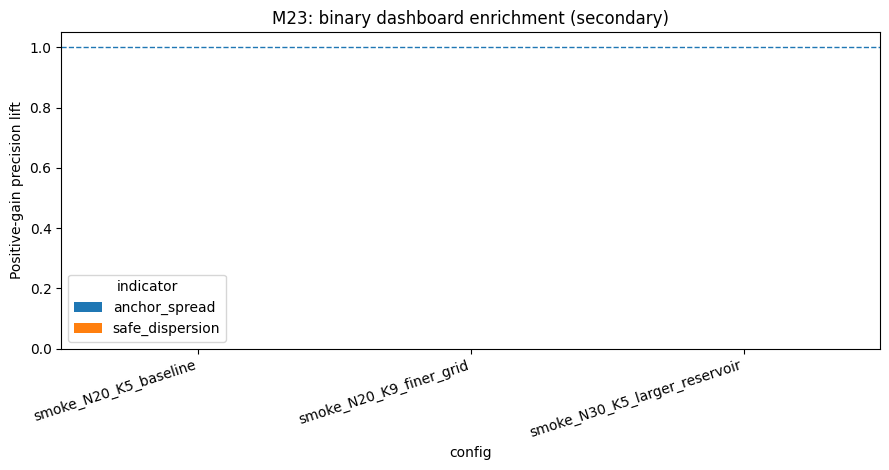

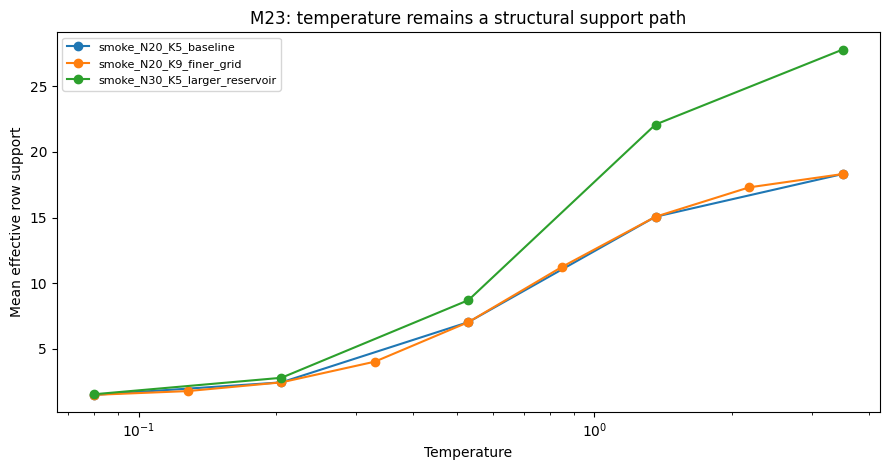

In [10]:
# ============================================================
# Manuscript-ready figures (one plot per file)
# ============================================================

labels = paper_summary["config"].tolist()
positions = np.arange(len(labels))

plt.figure(figsize=(9, 4.8))
plt.bar(positions, paper_summary["safe_width_fraction"])
plt.xticks(positions, labels, rotation=18, ha="right")
plt.ylabel("Mean safe-region width fraction")
plt.title("M23: safe-region width under grid and size changes")
plt.tight_layout()
plt.savefig(OUTDIR / "m23_safe_width_fraction.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4.8))
plt.bar(positions, paper_summary["containment_lift_near"])
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xticks(positions, labels, rotation=18, ha="right")
plt.ylabel("Near-oracle containment lift")
plt.title("M23: validation-safe region vs same-width intervals")
plt.tight_layout()
plt.savefig(OUTDIR / "m23_containment_lift.png", dpi=220, bbox_inches="tight")
plt.show()


indicator_plot = primary_dash.pivot(
    index="config", columns="indicator", values="high_minus_low_mean_gain"
).reindex(labels)
indicator_plot.plot(kind="bar", figsize=(9, 4.8))
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.ylabel("High-minus-low mean safe-region gain")
plt.title("M23: corrected continuous dashboard enrichment")
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.savefig(
    OUTDIR / "m23_dashboard_continuous_enrichment.png",
    dpi=220, bbox_inches="tight"
)
plt.show()

precision_plot = primary_dash.pivot(
    index="config", columns="indicator", values="precision_lift"
).reindex(labels)
precision_plot.plot(kind="bar", figsize=(9, 4.8))
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("Positive-gain precision lift")
plt.title("M23: binary dashboard enrichment (secondary)")
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.savefig(
    OUTDIR / "m23_dashboard_precision_lift.png",
    dpi=220, bbox_inches="tight"
)
plt.show()

support_plot = (
    structural_df.groupby(["config", "N", "K", "point_idx", "tau"], as_index=False)
    .agg(effective_support_mean=("effective_support_mean", "mean"))
)
plt.figure(figsize=(9, 4.8))
for config, group in support_plot.groupby("config", sort=False):
    ordered = group.sort_values("tau")
    plt.plot(
        ordered["tau"], ordered["effective_support_mean"],
        marker="o", label=config
    )
plt.xscale("log")
plt.xlabel("Temperature")
plt.ylabel("Mean effective row support")
plt.title("M23: temperature remains a structural support path")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR / "m23_support_vs_temperature.png", dpi=220, bbox_inches="tight")
plt.show()


In [11]:
# ============================================================
# Dependency-free manuscript table and conservative wording
# ============================================================

paper_columns = [
    "config", "N", "K",
    "safe_width_fraction",
    "safe_contains_near", "matched_near_rate", "containment_lift_near",
    "safe_gain", "safe_minus_matched_gain",
    "high_minus_low_mean_gain_safe_dispersion",
    "high_minus_low_mean_gain_anchor_spread",
    "indicator_gain_corr_safe_dispersion",
    "indicator_gain_corr_anchor_spread",
    "precision_lift_safe_dispersion",
    "precision_lift_anchor_spread",
    "support_fraction_range", "spectral_radius_range",
    "core_robustness_pass",
    "dashboard_continuous_pass",
    "dashboard_binary_pass",
]
paper_table = paper_summary[paper_columns].copy()
paper_table.to_csv(OUTDIR / "m23_table_for_manuscript.csv", index=False)


def simple_latex_table(df: pd.DataFrame, float_digits: int = 4) -> str:
    """Minimal LaTeX tabular exporter; does not require jinja2."""
    def fmt(value):
        if pd.isna(value):
            return "--"
        if isinstance(value, (bool, np.bool_)):
            return "yes" if bool(value) else "no"
        if isinstance(value, (float, np.floating)):
            return f"{float(value):.{float_digits}f}"
        text = str(value)
        replacements = {
            "\\": r"\textbackslash{}",
            "_": r"\_",
            "%": r"\%",
            "&": r"\&",
            "#": r"\#",
        }
        for old, new in replacements.items():
            text = text.replace(old, new)
        return text

    cols = list(df.columns)
    lines = [
        r"\begin{tabular}{" + "l" * len(cols) + "}",
        r"\hline",
        " & ".join(fmt(c) for c in cols) + r" \\",
        r"\hline",
    ]
    for _, row in df.iterrows():
        lines.append(" & ".join(fmt(row[c]) for c in cols) + r" \\")
    lines.extend([r"\hline", r"\end{tabular}"])
    return "\n".join(lines)


latex_table = simple_latex_table(paper_table)
(OUTDIR / "m23_table_for_manuscript.tex").write_text(
    latex_table, encoding="utf-8"
)

all_core_pass = bool(paper_summary["core_robustness_pass"].all())
all_continuous_pass = bool(paper_summary["dashboard_continuous_pass"].all())
all_binary_pass = bool(paper_summary["dashboard_binary_pass"].all())

if all_core_pass:
    core_sentence = (
        "The validation-safe region remained enriched relative to all contiguous "
        "same-width intervals on both a nested 25-point temperature grid and at "
        "reservoir size N=150, while safe-minus-matched-region gain remained positive."
    )
else:
    core_sentence = (
        "The safe-region result was not directionally stable in every configuration; "
        "the grid/size experiment should be reported as a boundary audit rather than "
        "as a uniform robustness confirmation."
    )

if all_continuous_pass:
    dashboard_sentence = (
        "After excluding singleton safe regions, at least one primary label-free "
        "indicator retained positive continuous association with movement headroom "
        "in every configuration."
    )
else:
    dashboard_sentence = (
        "After excluding singleton safe regions, continuous dashboard association "
        "was not positive in every configuration and should not be claimed as "
        "grid- or size-invariant."
    )

if all_binary_pass:
    binary_sentence = (
        "Binary positive-gain precision lift also remained above one in every configuration."
    )
else:
    binary_sentence = (
        "Binary positive-gain precision lift was less stable and is retained only as "
        "a secondary finite-sample diagnostic."
    )

paragraph = " ".join([
    "A one-factor-at-a-time robustness audit changed grid density and reservoir size separately.",
    core_sentence,
    dashboard_sentence,
    binary_sentence,
    "Absolute widths and lift factors remain finite-grid empirical quantities."
])

(OUTDIR / "m23_manuscript_paragraph.txt").write_text(
    paragraph, encoding="utf-8"
)

print(paragraph)
print("\nSaved outputs to:", OUTDIR.resolve())

A one-factor-at-a-time robustness audit changed grid density and reservoir size separately. The safe-region result was not directionally stable in every configuration; the grid/size experiment should be reported as a boundary audit rather than as a uniform robustness confirmation. After excluding singleton safe regions, continuous dashboard association was not positive in every configuration and should not be claimed as grid- or size-invariant. Binary positive-gain precision lift was less stable and is retained only as a secondary finite-sample diagnostic. Absolute widths and lift factors remain finite-grid empirical quantities.

Saved outputs to: /mnt/data/temperature-calibrated-reservoirs-reproducibility/tests/_m23_smoke_outputs


## Decision rule

Use M23 in the paper only after reading the three decisions separately:

- **Core robustness:** containment lift \(>1\) and safe-minus-matched gain \(>0\) in all configurations.
- **Continuous dashboard robustness:** at least one primary indicator has both positive correlation with safe-region headroom and positive high-minus-low mean headroom.
- **Binary dashboard robustness:** positive-gain precision lift \(>1\); this is secondary and may be less stable when the base positive-gain rate is small.

A singleton safe region is not evidence against the dashboard. It means that no within-safe-region
prediction variability exists to measure, so that case is marked undefined for dashboard analysis.

The notebook does not claim alternative-topology robustness.